<a href="https://colab.research.google.com/github/shehzadtm/KhuramFiles/blob/main/Support_Resistance2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

/tmp/ipykernel_2729/1985449050.py:12: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, period=period)
[*********************100%***********************]  1 of 1 completed



--- CRM Key Levels Found ---
Identified Support Levels ($): [np.float64(146.32), np.float64(155.15), np.float64(163.5), np.float64(173.69), np.float64(220.48), np.float64(224.58), np.float64(232.3)]
Identified Resistance Levels ($): [np.float64(190.18), np.float64(193.06), np.float64(203.82), np.float64(210.8), np.float64(255.83), np.float64(266.21)]


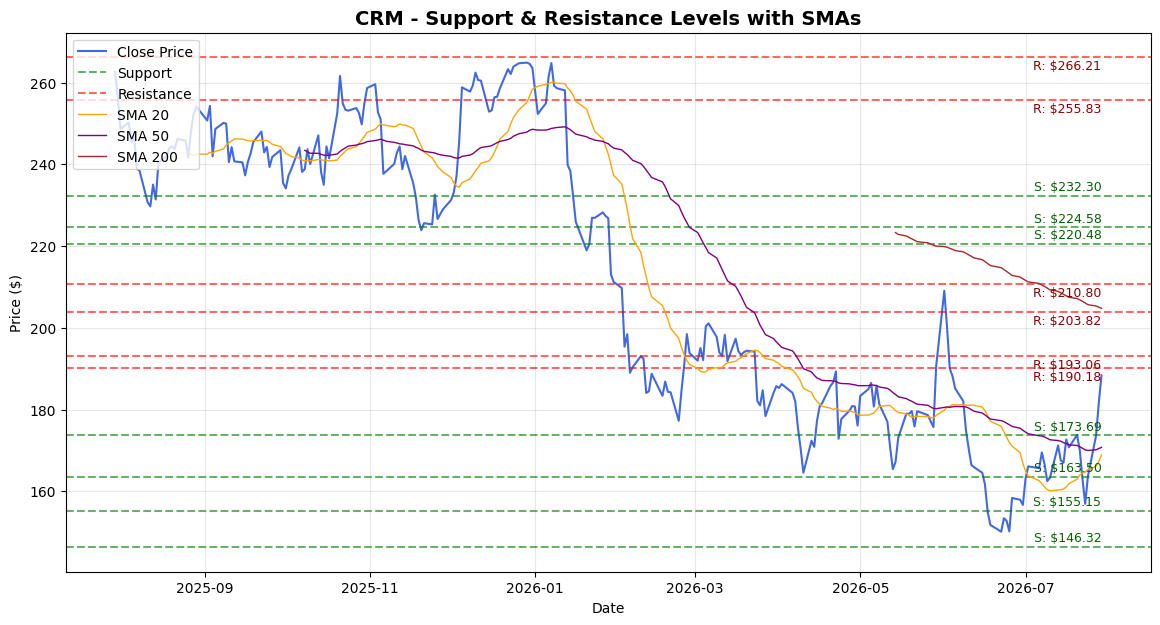


--- Trading Judgment for CRM ---
Current Price (2026-07-29): $188.38
SMA 20: $168.85, SMA 50: $170.75, SMA 200: $204.78
Price is mixed relative to SMAs, indicating potential consolidation or uncertain trend.
No recent Golden Cross detected.
No recent Death Cross detected.
Last Price crossed above SMA 20 on: 2026-07-27.
Last Price crossed below SMA 20 on: 2026-07-22.
Nearest Support: $173.69 (current price is 8.46% above).
Nearest Resistance: $190.18 (current price is 0.96% below).
Price is very close to a key resistance level. This could indicate a selling opportunity or a potential breakout if it crosses.
Overall Sentiment: Mixed long-term trend. Positive short-to-medium term momentum. Further technical analysis is recommended for a definitive 'Buy'/'Sell' decision.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import yfinance as yf
from scipy.signal import argrelextrema


def get_stock_data_and_levels(ticker, period="1y", window=10):
    """Downloads stock data, calculates support and resistance levels,
    and computes SMAs."""
    # 1. Download historical stock data
    df = yf.download(ticker, period=period)

    if df.empty:
        print(f"No data found for ticker: {ticker}")
        return None, None, None, None, None, None

    # Flatten columns if multi-indexed (fix for recent yfinance updates)
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)

    # Calculate SMAs
    df['SMA_20'] = df['Close'].rolling(window=20).mean()
    df['SMA_50'] = df['Close'].rolling(window=50).mean()
    df['SMA_200'] = df['Close'].rolling(window=200).mean()

    # 2. Find local maxima (Resistance) and minima (Support)
    # 'window' is the number of points to check on each side of the current point
    df["Min"] = df.iloc[
        argrelextrema(df["Low"].values, np.less_equal, order=window)[0]
    ]["Low"]
    df["Max"] = df.iloc[
        argrelextrema(df["High"].values, np.greater_equal, order=window)[0]
    ]["High"]

    # Extract unique price levels, dropping NaN entries
    supports = df["Min"].dropna().unique()
    resistances = df["Max"].dropna().unique()

    # 3. Filter out clusters that are too close to each other (consolidation)
    # We group levels that are within 1.5% of each other
    def merge_levels(levels, threshold_pct=0.015):
        if len(levels) == 0:
            return []
        sorted_levels = np.sort(levels)
        merged = []
        current_bin = [sorted_levels[0]]

        for r in sorted_levels[1:]:
            if (r - current_bin[-1]) / current_bin[-1] < threshold_pct:
                current_bin.append(r)
            else:
                merged.append(np.mean(current_bin))
                current_bin = [r]
        merged.append(np.mean(current_bin))
        return merged

    clean_supports = merge_levels(supports)
    clean_resistances = merge_levels(resistances)

    return df, clean_supports, clean_resistances


def plot_stock_data_with_levels_and_smas(df, ticker, supports, resistances):
    """Plots the stock closing price alongside the calculated levels and SMAs."""
    plt.figure(figsize=(14, 7))
    plt.plot(df.index, df["Close"], label="Close Price", color="royalblue", lw=1.5)

    # Plot cleaned Support lines
    for sup in supports:
        plt.axhline(
            y=sup,
            color="green",
            linestyle="--",
            alpha=0.6,
            label="Support" if sup == supports[0] else "", # Only label first instance
        )
        plt.text(df.index[-1], sup + (df['Close'].max() - df['Close'].min())*0.005, f'S: ${sup:.2f}', color='darkgreen', fontsize=9, verticalalignment='bottom', horizontalalignment='right')

    # Plot cleaned Resistance lines
    for res in resistances:
        plt.axhline(
            y=res,
            color="red",
            linestyle="--",
            alpha=0.6,
            label="Resistance" if res == resistances[0] else "", # Only label first instance
        )
        plt.text(df.index[-1], res - (df['Close'].max() - df['Close'].min())*0.005, f'R: ${res:.2f}', color='darkred', fontsize=9, verticalalignment='top', horizontalalignment='right')

    # Plot SMAs
    plt.plot(df.index, df['SMA_20'], label='SMA 20', color='orange', linestyle='-', lw=1)
    plt.plot(df.index, df['SMA_50'], label='SMA 50', color='purple', linestyle='-', lw=1)
    plt.plot(df.index, df['SMA_200'], label='SMA 200', color='brown', linestyle='-', lw=1)

    plt.title(f"{ticker} - Support & Resistance Levels with SMAs", fontsize=14, fontweight="bold")
    plt.xlabel("Date")
    plt.ylabel("Price ($)")
    plt.legend(loc="upper left")
    plt.grid(True, alpha=0.3)
    plt.show()

def analyze_entry_points(df, sup_levels, res_levels, ticker_symbol):
    """Analyzes the stock data for potential entry points based on SMA crossovers and S/R levels."""
    conclusion = [f"--- Trading Judgment for {ticker_symbol} ---"]

    current_price = df['Close'].iloc[-1]
    last_date = df.index[-1].strftime('%Y-%m-%d')
    conclusion.append(f"Current Price ({last_date}): ${current_price:.2f}")

    # SMA Status
    sma_20 = df['SMA_20'].iloc[-1] if not df['SMA_20'].isnull().all() else np.nan
    sma_50 = df['SMA_50'].iloc[-1] if not df['SMA_50'].isnull().all() else np.nan
    sma_200 = df['SMA_200'].iloc[-1] if not df['SMA_200'].isnull().all() else np.nan

    if not np.isnan(sma_20) and not np.isnan(sma_50) and not np.isnan(sma_200):
        conclusion.append(f"SMA 20: ${sma_20:.2f}, SMA 50: ${sma_50:.2f}, SMA 200: ${sma_200:.2f}")

        if current_price > sma_20 and current_price > sma_50 and current_price > sma_200:
            conclusion.append("Price is currently above all key moving averages (20, 50, 200-day SMAs), indicating strong bullish momentum.")
        elif current_price < sma_20 and current_price < sma_50 and current_price < sma_200:
            conclusion.append("Price is currently below all key moving averages (20, 50, 200-day SMAs), indicating strong bearish momentum.")
        elif current_price > sma_50 and current_price > sma_200:
            conclusion.append("Price is above the 50 and 200-day SMAs, suggesting a bullish trend, though it might be consolidating below SMA 20.")
        elif current_price < sma_50 and current_price < sma_200:
            conclusion.append("Price is below the 50 and 200-day SMAs, suggesting a bearish trend, though it might be consolidating above SMA 20.")
        else:
            conclusion.append("Price is mixed relative to SMAs, indicating potential consolidation or uncertain trend.")
    else:
        conclusion.append("Not enough data to calculate all SMAs for comparison.")

    # Golden Cross (50-day SMA crosses above 200-day SMA) - bullish signal
    if not df['SMA_50'].isnull().all() and not df['SMA_200'].isnull().all():
        golden_cross_dates = df[(df['SMA_50'].shift(1) < df['SMA_200'].shift(1)) &
                                (df['SMA_50'] > df['SMA_200'])].index

        if not golden_cross_dates.empty:
            conclusion.append(f"Golden Cross (SMA 50 > SMA 200) occurred on: {golden_cross_dates[-1].strftime('%Y-%m-%d')}. This is often considered a strong bullish signal.")
        else:
            conclusion.append("No recent Golden Cross detected.")

        # Death Cross (50-day SMA crosses below 200-day SMA) - bearish signal
        death_cross_dates = df[(df['SMA_50'].shift(1) > df['SMA_200'].shift(1)) &
                               (df['SMA_50'] < df['SMA_200'])].index

        if not death_cross_dates.empty:
            conclusion.append(f"Death Cross (SMA 50 < SMA 200) occurred on: {death_cross_dates[-1].strftime('%Y-%m-%d')}. This is often considered a strong bearish signal.")
        else:
            conclusion.append("No recent Death Cross detected.")

    # Price crossing above/below 20-day SMA
    if not df['SMA_20'].isnull().all():
        price_cross_20_dates = df[(df['Close'].shift(1) < df['SMA_20'].shift(1)) &
                                  (df['Close'] > df['SMA_20'])].index

        if not price_cross_20_dates.empty and price_cross_20_dates[-1] == df.index[-1]:
            conclusion.append(f"Price crossed above SMA 20 on the most recent day ({price_cross_20_dates[-1].strftime('%Y-%m-%d')}). This could indicate short-term upward momentum.")
        elif not price_cross_20_dates.empty:
            conclusion.append(f"Last Price crossed above SMA 20 on: {price_cross_20_dates[-1].strftime('%Y-%m-%d')}.")

        price_cross_20_below_dates = df[(df['Close'].shift(1) > df['SMA_20'].shift(1)) &
                                        (df['Close'] < df['SMA_20'])].index
        if not price_cross_20_below_dates.empty and price_cross_20_below_dates[-1] == df.index[-1]:
            conclusion.append(f"Price crossed below SMA 20 on the most recent day ({price_cross_20_below_dates[-1].strftime('%Y-%m-%d')}). This could indicate short-term downward momentum.")
        elif not price_cross_20_below_dates.empty:
            conclusion.append(f"Last Price crossed below SMA 20 on: {price_cross_20_below_dates[-1].strftime('%Y-%m-%d')}.")

    # Proximity to Support/Resistance
    nearest_support = None
    if sup_levels:
        # Closest support below current price
        supports_below = [s for s in sup_levels if current_price > s]
        if supports_below:
            nearest_support = max(supports_below)
        else:
            # If no supports below, find the closest one overall (could be above)
            nearest_support = min(sup_levels, key=lambda x: abs(x - current_price))

    nearest_resistance = None
    if res_levels:
        # Closest resistance above current price
        resistances_above = [r for r in res_levels if r > current_price]
        if resistances_above:
            nearest_resistance = min(resistances_above)
        else:
            # If no resistances above, find the closest one overall (could be below)
            nearest_resistance = min(res_levels, key=lambda x: abs(x - current_price))

    if nearest_support is not None:
        dist_to_support_pct = ((current_price - nearest_support) / nearest_support) * 100
        conclusion.append(f"Nearest Support: ${nearest_support:.2f} (current price is {dist_to_support_pct:.2f}% above).")
        if 0 < dist_to_support_pct < 2: # Within 2% above support
            conclusion.append("Price is very close to a key support level. This could be a potential buying opportunity if it holds, or a bearish signal if it breaks.")
        elif dist_to_support_pct < 0:
             conclusion.append("Price is below a key support level. This could be a bearish signal, potentially turning the old support into new resistance.")

    if nearest_resistance is not None:
        dist_to_resistance_pct = ((nearest_resistance - current_price) / current_price) * 100
        conclusion.append(f"Nearest Resistance: ${nearest_resistance:.2f} (current price is {dist_to_resistance_pct:.2f}% below).")
        if 0 < dist_to_resistance_pct < 2: # Within 2% below resistance
            conclusion.append("Price is very close to a key resistance level. This could indicate a selling opportunity or a potential breakout if it crosses.")
        elif dist_to_resistance_pct < 0:
             conclusion.append("Price is above a key resistance level. This could be a bullish signal, potentially turning the old resistance into new support.")

    final_recommendation = "Overall Sentiment: "
    # Simplified recommendation logic
    if current_price > sma_50 and current_price > sma_200 and not np.isnan(sma_50) and not np.isnan(sma_200):
        final_recommendation += "Bullish long-term trend. "
    elif current_price < sma_50 and current_price < sma_200 and not np.isnan(sma_50) and not np.isnan(sma_200):
        final_recommendation += "Bearish long-term trend. "
    else:
        final_recommendation += "Mixed long-term trend. "

    if current_price > sma_20 and current_price > sma_50 and not np.isnan(sma_20) and not np.isnan(sma_50):
        final_recommendation += "Positive short-to-medium term momentum. "
    elif current_price < sma_20 and current_price < sma_50 and not np.isnan(sma_20) and not np.isnan(sma_50):
        final_recommendation += "Negative short-to-medium term momentum. "

    if nearest_support is not None and (0 < ((current_price - nearest_support) / nearest_support) * 100 < 2) and current_price > sma_20:
        final_recommendation += "Potential 'Buy' opportunity if support holds with positive short-term momentum."
    elif nearest_resistance is not None and (0 < ((nearest_resistance - current_price) / current_price) * 100 < 2) and current_price < sma_20:
        final_recommendation += "Potential 'Sell' or 'Hold' near resistance with negative short-term momentum."
    elif nearest_resistance is not None and current_price > nearest_resistance and current_price > sma_20:
        final_recommendation += "Price has broken above resistance, which can be a strong bullish signal. Consider 'Buy' on retest of old resistance as new support."
    elif nearest_support is not None and current_price < nearest_support and current_price < sma_20:
        final_recommendation += "Price has broken below support, which can be a strong bearish signal. Consider 'Sell' on retest of old support as new resistance."
    else:
        final_recommendation += "Further technical analysis is recommended for a definitive 'Buy'/'Sell' decision."

    conclusion.append(final_recommendation)
    return "\n".join(conclusion)


# --- User Configuration ---
ticker_symbol = "CRM"  # <--- Change this to analyze a different stock
analysis_period = "1y"
window_size = 10 # For argrelextrema in S/R calculation

# --- Data Fetching and Analysis ---
df, sup_levels, res_levels = get_stock_data_and_levels(
    ticker_symbol, period=analysis_period, window=window_size
)

if df is None or df.empty:
    print(f"Could not retrieve data for {ticker_symbol}. Please check the ticker symbol or period.")
else:
    print(f"\n--- {ticker_symbol} Key Levels Found ---")
    print("Identified Support Levels ($):", [round(x, 2) for x in sup_levels])
    print("Identified Resistance Levels ($):", [round(x, 2) for x in res_levels])

    # Plotting
    plot_stock_data_with_levels_and_smas(df, ticker_symbol, sup_levels, res_levels)

    # Trading Judgment
    trading_judgment = analyze_entry_points(df, sup_levels, res_levels, ticker_symbol)
    print("\n" + trading_judgment)

Enter Stock Ticker Symbol (e.g., RDW, NVDA, GOOGL): MU


/tmp/ipykernel_593/505202260.py:25: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(symbol, period="1y", interval="1d") # Changed from 10y to 1y
[*********************100%***********************]  1 of 1 completed


Fetching live data for MU from Yahoo Finance...

 TECHNICAL ANALYSIS REPORT FOR $MU
• Latest Close Price : $874.66
• 20 SMA / 50 SMA    : $919.31 / $962.26
• Relative Vol (RVOL): 1.32x
• MFI (14)           : 39.15
• RSI (14)           : 46.62
• MACD / Signal      : -34.62 / $-19.44
• ADX / +DI / -DI    : 59.29 / 11.05 / 51.21
-----------------------------------------------------------------
► EXECUTIVE SUMMARY:
  [S/R Levels]:
    Identified Support Levels ($):  [np.float64(103.21), np.float64(192.4), np.float64(221.47), np.float64(311.44), np.float64(357.46), np.float64(363.69), np.float64(737.88)]
    Identified Resistance Levels ($):  [np.float64(128.39), np.float64(260.33), np.float64(455.24), np.float64(471.07), np.float64(1254.81)]
    Nearest Support: $737.88 (current price is 18.54% above).
    Nearest Resistance: $1254.81 (current price is 43.46% below).
  [Trend]: Bearish Structure. Price is trapped below key moving average resistances.
  [Volume]: Average Volume. Liquidity 

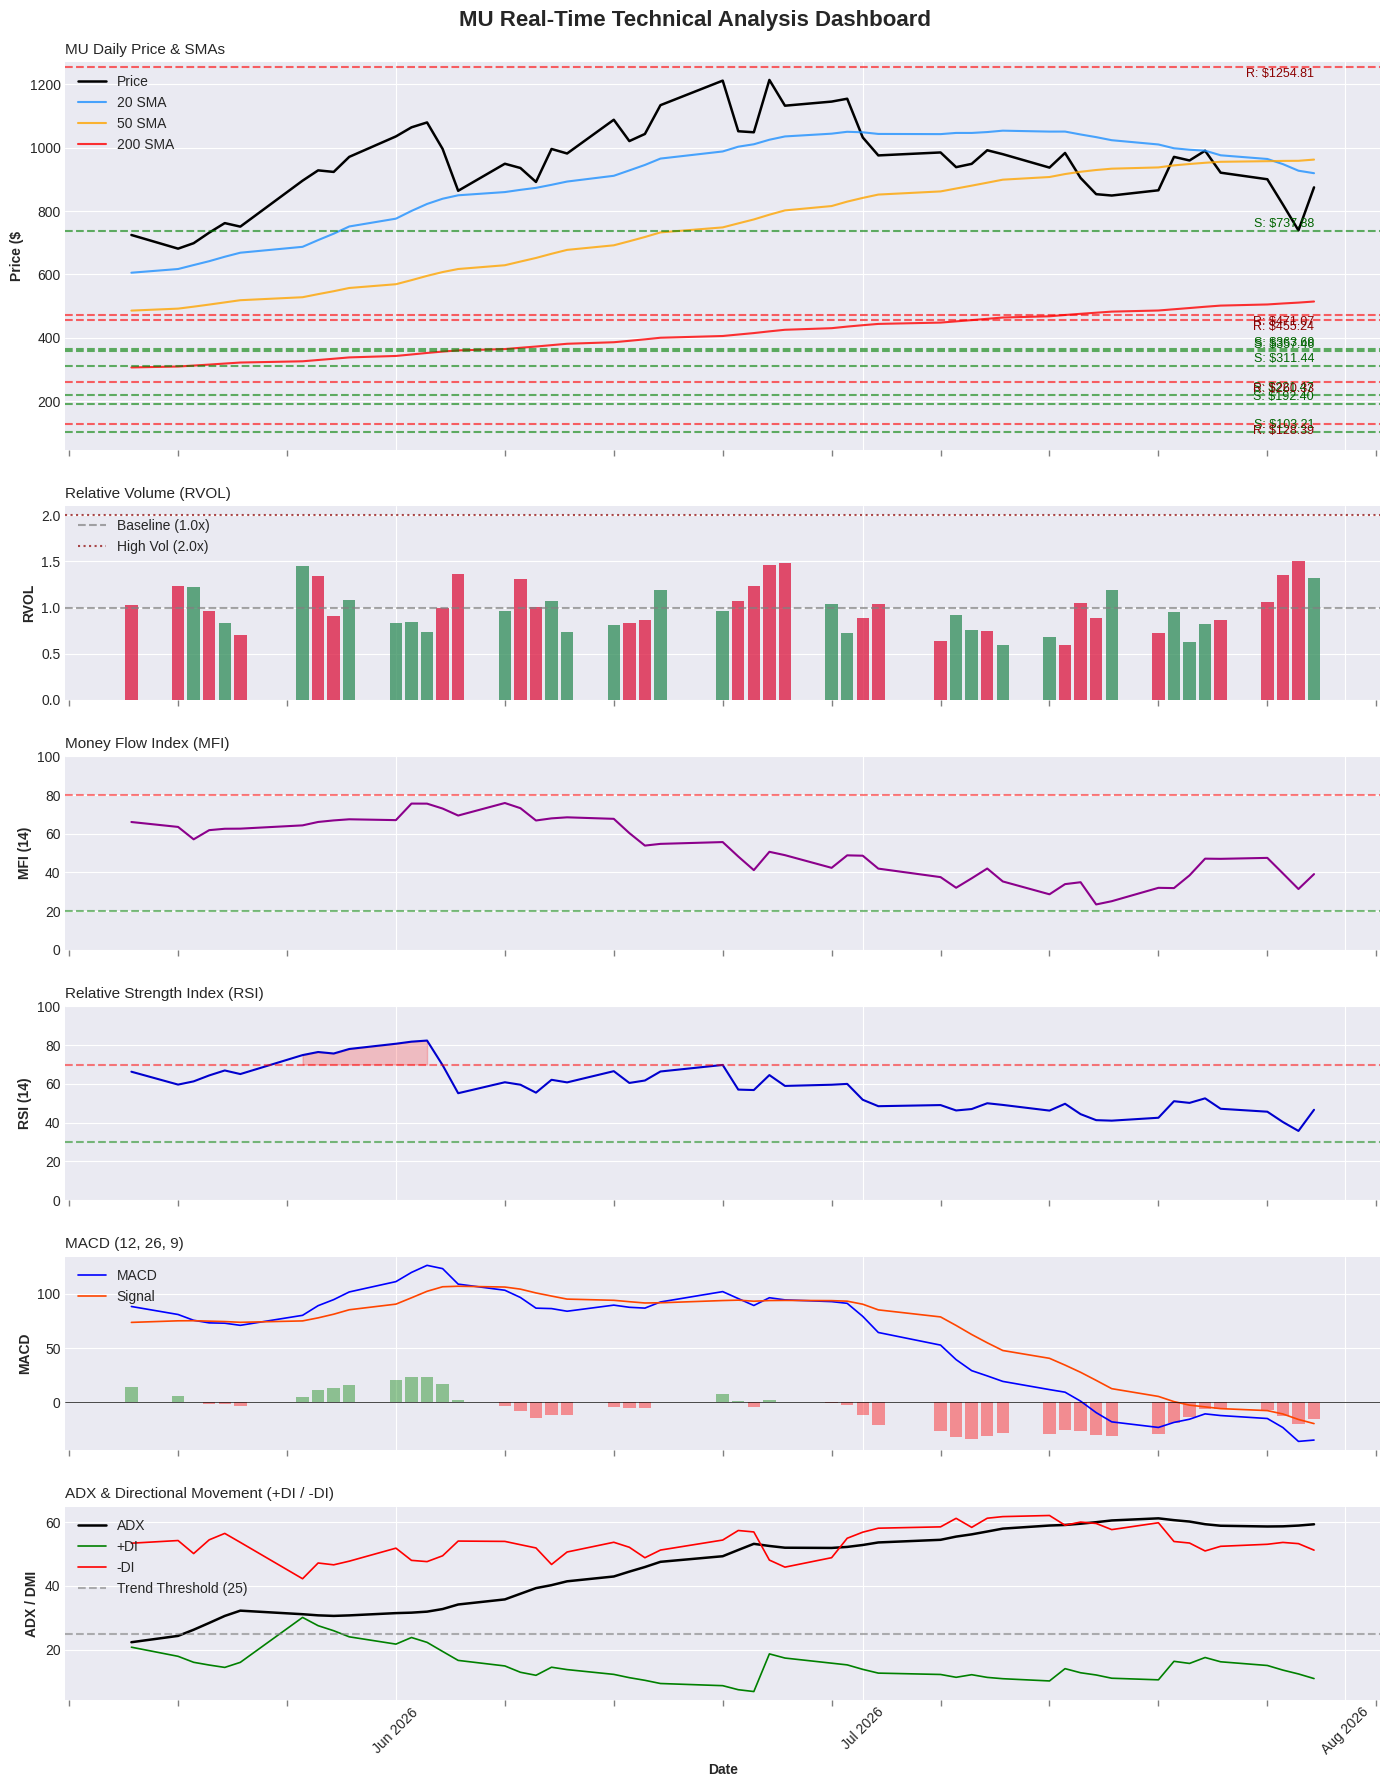

In [5]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.dates as mdates
from scipy.signal import argrelextrema


def analyze_and_plot_stock():
    # 1. PROMPT USER FOR TICKER
    symbol = (
        input("Enter Stock Ticker Symbol (e.g., RDW, NVDA, GOOGL): ")
        .strip()
        .upper()
    )
    if not symbol:
        # Default to a well-known ticker if user input is empty or invalid for demonstration
        print("No ticker entered. Using 'AAPL' as a default.")
        symbol = "AAPL"
    # symbol = "AAPL" # Temporarily hardcoding for demonstration

    print(f"\nFetching live data for {symbol} from Yahoo Finance...")

    # Download 8 months of daily data to ensure 200 SMA calculation window
    df = yf.download(symbol, period="1y", interval="1d") # Changed from 10y to 1y

    if df.empty:
        print(
            f"Error: No data found for ticker '{symbol}'. Please check the symbol."
        )
        return

    # Clean multi-index columns if returned by newer yfinance versions
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)

    df.dropna(inplace=True)

    # 2. CALCULATE TECHNICAL INDICATORS
    # Moving Averages
    df["SMA_20"] = df["Close"].rolling(window=20).mean()
    df["SMA_50"] = df["Close"].rolling(window=50).mean()
    df["SMA_200"] = df["Close"].rolling(window=200).mean()

    # Relative Volume (RVOL)
    df["Vol_SMA_20"] = df["Volume"].rolling(window=20).mean()
    df["RVOL"] = df["Volume"] / df["Vol_SMA_20"]

    # Money Flow Index (MFI 14)
    typical_price = (df["High"] + df["Low"] + df["Close"]) / 3
    raw_money_flow = typical_price * df["Volume"]

    price_diff = typical_price.diff()

    positive_flow = pd.Series(0.0, index=df.index)
    negative_flow = pd.Series(0.0, index=df.index)
    positive_flow[price_diff > 0] = raw_money_flow[price_diff > 0]
    negative_flow[price_diff < 0] = raw_money_flow[price_diff < 0]

    pos_mf_14 = positive_flow.rolling(window=14).sum()
    neg_mf_14 = negative_flow.rolling(window=14).sum()
    mfi_ratio = pos_mf_14 / neg_mf_14
    df["MFI_14"] = 100 - (100 / (1 + mfi_ratio))

    # Relative Strength Index (RSI 14)
    delta = df["Close"].diff()
    gain = delta.where(delta > 0, 0.0)
    loss = -delta.where(delta < 0, 0.0)
    avg_gain = gain.ewm(alpha=1 / 14, min_periods=14).mean()
    avg_loss = loss.ewm(alpha=1 / 14, min_periods=14).mean()
    rs = avg_gain / avg_loss
    df["RSI_14"] = 100 - (100 / (1 + rs))

    # MACD (12, 26, 9)
    ema_12 = df["Close"].ewm(span=12, adjust=False).mean()
    ema_26 = df["Close"].ewm(span=26, adjust=False).mean()
    df["MACD"] = ema_12 - ema_26
    df["MACD_Signal"] = df["MACD"].ewm(span=9, adjust=False).mean()
    df["MACD_Hist"] = df["MACD"] - df["MACD_Signal"]

    # ADX & DMI (14 Period)
    up_move = df["High"].diff()
    down_move = df["Low"].diff().abs()
    plus_dm = np.where((up_move > down_move) & (up_move > 0), up_move, 0.0)
    minus_dm = np.where((down_move > up_move) & (down_move > 0), down_move, 0.0)

    tr1 = df["High"] - df["Low"]
    tr2 = (df["High"] - df["Close"].shift(1)).abs()
    tr3 = (df["Low"] - df["Close"].shift(1)).abs()
    tr = pd.DataFrame({"tr1": tr1, "tr2": tr2, "tr3": tr3}).max(axis=1)

    atr_14 = tr.ewm(alpha=1 / 14, min_periods=14).mean()
    df["Plus_DI"] = (
        100 * pd.Series(plus_dm, index=df.index).ewm(alpha=1 / 14).mean() / atr_14
    )
    df["Minus_DI"] = (
        100 * pd.Series(minus_dm, index=df.index).ewm(alpha=1 / 14).mean() / atr_14
    )
    dx = (100 * (df["Plus_DI"] - df["Minus_DI"]).abs()) / (
        df["Plus_DI"] + df["Minus_DI"]
    )
    df["ADX"] = dx.ewm(alpha=1 / 14, min_periods=14).mean()

    # Calculate Support and Resistance levels
    window_size = 10 # Parameter for argrelextrema
    df["Min"] = df.iloc[
        argrelextrema(df["Low"].values, np.less_equal, order=window_size)[0]
    ]["Low"]
    df["Max"] = df.iloc[
        argrelextrema(df["High"].values, np.greater_equal, order=window_size)[0]
    ]["High"]

    supports_raw = df["Min"].dropna().unique()
    resistances_raw = df["Max"].dropna().unique()

    # Helper function to merge close levels
    def merge_levels(levels, threshold_pct=0.015):
        if len(levels) == 0:
            return []
        sorted_levels = np.sort(levels)
        merged = []
        current_bin = [sorted_levels[0]]

        for r in sorted_levels[1:]: # Iterate through sorted_levels starting from the second element
            if (r - current_bin[-1]) / current_bin[-1] < threshold_pct:
                current_bin.append(r)
            else:
                merged.append(np.mean(current_bin))
                current_bin = [r]
        merged.append(np.mean(current_bin))
        return merged

    clean_supports = merge_levels(supports_raw)
    clean_resistances = merge_levels(resistances_raw)

    # Create df_clean by dropping NaNs only from the indicator columns,
    # not from the sparse 'Min' and 'Max' columns. These sparse columns
    # are only used for S/R levels, which have already been extracted.
    columns_to_keep = [col for col in df.columns if col not in ['Min', 'Max']]
    df_clean = df[columns_to_keep].dropna().copy()

    if df_clean.empty:
        print(
            f"Error: Not enough data after calculating indicators for ticker '{symbol}'. "
            "Try a longer historical period or a different ticker."
        )
        return

    latest = df_clean.iloc[-1]
    current_price = latest['Close']

    # 3. PRINT AUTOMATED TECHNICAL ANALYSIS
    print("\n" + "=" * 65)
    print(f" TECHNICAL ANALYSIS REPORT FOR ${symbol}")
    print("=" * 65)
    print(f"• Latest Close Price : ${current_price:.2f}")
    print(f"• 20 SMA / 50 SMA    : ${latest['SMA_20']:.2f} / ${latest['SMA_50']:.2f}")
    print(f"• Relative Vol (RVOL): {latest['RVOL']:.2f}x")
    print(f"• MFI (14)           : {latest['MFI_14']:.2f}")
    print(f"• RSI (14)           : {latest['RSI_14']:.2f}")
    print(
        f"• MACD / Signal      : {latest['MACD']:.2f} / ${latest['MACD_Signal']:.2f}"
    )
    print(f"• ADX / +DI / -DI    : {latest['ADX']:.2f} / {latest['Plus_DI']:.2f} / {latest['Minus_DI']:.2f}")
    print("-" * 65)

    # Narrative Synthesis
    print("► EXECUTIVE SUMMARY:")

    # --- Support & Resistance Analysis ---
    print("  [S/R Levels]:")
    if clean_supports:
        print("    Identified Support Levels ($): ", [round(x, 2) for x in clean_supports])
    if clean_resistances:
        print("    Identified Resistance Levels ($): ", [round(x, 2) for x in clean_resistances])

    nearest_support = None
    if clean_supports:
        supports_below = [s for s in clean_supports if current_price > s]
        if supports_below:
            nearest_support = max(supports_below)
        else:
            # If no supports below, find the closest one overall (could be above)!
            nearest_support = min(clean_supports, key=lambda x: abs(x - current_price))

    nearest_resistance = None
    if clean_resistances:
        resistances_above = [r for r in clean_resistances if r > current_price]
        if resistances_above:
            nearest_resistance = min(resistances_above)
        else:
            # If no resistances above, find the closest one overall (could be below)!
            nearest_resistance = min(clean_resistances, key=lambda x: abs(x - current_price))

    if nearest_support is not None:
        dist_to_support_pct = ((current_price - nearest_support) / nearest_support) * 100
        print(f"    Nearest Support: ${nearest_support:.2f} (current price is {dist_to_support_pct:.2f}% above).")
        if 0 < dist_to_support_pct < 2: # Within 2% above support!
            print("      Price is very close to a key support level. This could be a potential buying opportunity if it holds, or a bearish signal if it breaks.")
        elif dist_to_support_pct < 0:
             print("      Price is below a key support level. This could be a bearish signal, potentially turning the old support into new resistance.")

    if nearest_resistance is not None:
        dist_to_resistance_pct = ((nearest_resistance - current_price) / current_price) * 100
        print(f"    Nearest Resistance: ${nearest_resistance:.2f} (current price is {dist_to_resistance_pct:.2f}% below).")
        if 0 < dist_to_resistance_pct < 2: # Within 2% below resistance!
            print("      Price is very close to a key resistance level. This could indicate a selling opportunity or a potential breakout if it crosses.")
        elif dist_to_resistance_pct < 0:
             print("      Price is above a key resistance level. This could be a bullish signal, potentially turning the old resistance into new support.")

    # Trend Analysis
    if latest["Close"] > latest["SMA_20"] > latest["SMA_50"]:
        print(
            "  [Trend]: Bullish Alignment. Price is trading above both short (20) and medium (50) SMAs."
        )
    elif latest["Close"] < latest["SMA_20"] < latest["SMA_50"]:
        print(
            "  [Trend]: Bearish Structure. Price is trapped below key moving average resistances."
        )
    else:
        print(
            "  [Trend]: Mixed / Consolidation Phase. Price is oscillating between short-term SMAs."
        )

    # Volume & Liquidity Analysis
    if latest["RVOL"] > 1.8:
        print(
            f"  [Volume]: High Institutional Volume. RVOL at {latest['RVOL']:.2f}x signals significant participation."
        )
    elif latest["RVOL"] < 0.8:
        print(
            f"  [Volume]: Low Participation. RVOL at {latest['RVOL']:.2f}x reflects quiet institutional activity."
        )
    else:
        print(
            f"  [Volume]: Average Volume. Liquidity is steady at {latest['RVOL']:.2f}x baseline."
        )

    # Momentum & Money Flow
    if latest["RSI_14"] > 70 or latest["MFI_14"] > 80:
        print(
            "  [Momentum]: Overbought Territory. Caution advised against immediate breakout chasing."
        )
    elif latest["RSI_14"] < 30 or latest["MFI_14"] < 20:
        print(
            "  [Momentum]: Oversold Conditions. Downside momentum may be reaching exhaustion."
        )
    else:
        print(
            "  [Momentum]: Neutral Momentum. MFI & RSI are balanced in mid-range zones."
        )

    # Trend Strength (ADX)
    if latest["ADX"] > 25:
        direction = (
            "Bulls in control"
            if latest["Plus_DI"] > latest["Minus_DI"]
            else "Bears in control"
        )
        print(
            f"  [Strength]: Strong Trend Active (ADX = {latest['ADX']:.1f}). Direction: {direction}."
        )
    else:
        print(
            f"  [Strength]: Weak/Absent Trend (ADX = {latest['ADX']:.1f}). Market is currently range-bound."
        )

    # --- Final Recommendation Logic ---
    print("  [Recommendation]:")
    final_recommendation = "    " # Indent

    # SMA based sentiment
    if current_price > latest['SMA_50'] and current_price > latest['SMA_200']:
        final_recommendation += "Bullish long-term trend. "
    elif current_price < latest['SMA_50'] and current_price < latest['SMA_200']:
        final_recommendation += "Bearish long-term trend. "
    else:
        final_recommendation += "Mixed long-term trend. "

    if current_price > latest['SMA_20'] and current_price > latest['SMA_50']:
        final_recommendation += "Positive short-to-medium term momentum. "
    elif current_price < latest['SMA_20'] and current_price < latest['SMA_50']:
        final_recommendation += "Negative short-to-medium term momentum. "
    else:
        final_recommendation += "Uncertain short-to-medium term momentum. "

    # S/R based actions
    if nearest_support is not None and (0 < ((current_price - nearest_support) / nearest_support) * 100 < 1.5): # within 1.5% of support
        if current_price > latest['SMA_20']:
            final_recommendation += "Consider 'Buy' if support holds and price bounces, especially with positive short-term momentum."
        else:
            final_recommendation += "Approaching support. Monitor for bounce or breakdown. Potential 'Buy' if signs of reversal, but be cautious if below SMAs."
    elif nearest_resistance is not None and (0 < ((nearest_resistance - current_price) / current_price) * 100 < 1.5): # within 1.5% of resistance
        if current_price < latest['SMA_20']:
            final_recommendation += "Consider 'Sell' or 'Hold' near resistance, especially with negative short-term momentum. Watch for rejection."
        else:
            final_recommendation += "Approaching resistance. Monitor for breakout or rejection. Potential 'Buy' on clear breakout, or 'Sell' if rejected."
    elif nearest_resistance is not None and current_price > nearest_resistance:
        final_recommendation += "Price has broken above resistance, which is a strong bullish signal. Consider 'Buy' on retest of old resistance (now new support) or continuation of upward trend."
    elif nearest_support is not None and current_price < nearest_support:
        final_recommendation += "Price has broken below support, which is a strong bearish signal. Consider 'Sell' on retest of old support (now new resistance) or continuation of downward trend."
    else:
        final_recommendation += "Currently trading between significant S/R levels. Look for confirmation of trend or consolidation patterns before acting."

    print(final_recommendation)
    print("=" * 65 + "\n")

    # 4. MULTI-PANE PLOTTING SETUP
    plt.style.use(
        "seaborn-v0_8-darkgrid"
        if "seaborn-v0_8-darkgrid" in plt.style.available
        else "default"
    )
    fig, axes = plt.subplots(
        6,
        1,
        figsize=(14, 18),
        sharex=True,
        gridspec_kw={"height_ratios": [2, 1, 1, 1, 1, 1]},
    )
    fig.suptitle(
        f"{symbol} Real-Time Technical Analysis Dashboard",
        fontsize=16,
        fontweight="bold",
        y=0.99,
    )

    # Pane 1: Price & SMAs
    axes[0].plot(
        df_clean.index, df_clean["Close"], label="Price", color="black", lw=1.8
    )
    axes[0].plot(
        df_clean.index,
        df_clean["SMA_20"],
        label="20 SMA",
        color="dodgerblue",
        alpha=0.8,
    )
    axes[0].plot(
        df_clean.index,
        df_clean["SMA_50"],
        label="50 SMA",
        color="orange",
        alpha=0.8,
    )
    if not df_clean["SMA_200"].isna().all():
        axes[0].plot(
            df_clean.index,
            df_clean["SMA_200"],
            label="200 SMA",
            color="red",
            alpha=0.8,
        )
    axes[0].set_ylabel("Price ($", fontweight="bold", fontsize=10)
    axes[0].legend(loc="upper left")
    axes[0].set_title(f"{symbol} Daily Price & SMAs", fontsize=11, loc="left")

    # Plot cleaned Support lines on the main price chart
    for sup in clean_supports:
        axes[0].axhline(
            y=sup,
            color="green",
            linestyle="--",
            alpha=0.6,
            label="Support" if sup == clean_supports[0] else "",
        )
        # Position text label to the right of the line
        axes[0].text(df_clean.index[-1],
                     sup + (df_clean['Close'].max() - df_clean['Close'].min())*0.005,
                     f'S: ${sup:.2f}',
                     color='darkgreen', fontsize=9, verticalalignment='bottom',
                     horizontalalignment='right')

    # Plot cleaned Resistance lines on the main price chart
    for res in clean_resistances:
        axes[0].axhline(
            y=res,
            color="red",
            linestyle="--",
            alpha=0.6,
            label="Resistance" if res == clean_resistances[0] else "",
        )
        # Position text label to the right of the line
        axes[0].text(df_clean.index[-1],
                     res - (df_clean['Close'].max() - df_clean['Close'].min())*0.005,
                     f'R: ${res:.2f}',
                     color='darkred', fontsize=9, verticalalignment='top',
                     horizontalalignment='right')

    # Pane 2: RVOL
    colors_rvol = [
        "crimson" if c < o else "seagreen"
        for c, o in zip(df_clean["Close"], df_clean["Open"])
    ]
    axes[1].bar(
        df_clean.index,
        df_clean["RVOL"],
        color=colors_rvol,
        alpha=0.75,
        width=0.8,
    )
    axes[1].axhline(
        1.0, color="gray", linestyle="--", alpha=0.7, label="Baseline (1.0x)"
    )
    axes[1].axhline(
        2.0, color="darkred", linestyle=":", alpha=0.7, label="High Vol (2.0x)"
    )
    axes[1].set_ylabel("RVOL", fontweight="bold", fontsize=10)
    axes[1].legend(loc="upper left")
    axes[1].set_title("Relative Volume (RVOL)", fontsize=11, loc="left")

    # Pane 3: MFI
    axes[2].plot(df_clean.index, df_clean["MFI_14"], color="darkmagenta", lw=1.5)
    axes[2].axhline(80, color="red", linestyle="--", alpha=0.5)
    axes[2].axhline(20, color="green", linestyle="--", alpha=0.5)
    axes[2].fill_between(
        df_clean.index,
        df_clean["MFI_14"],
        80,
        where=(df_clean["MFI_14"] >= 80),
        color="red",
        alpha=0.2,
    )
    axes[2].fill_between(
        df_clean.index,
        df_clean["MFI_14"],
        20,
        where=(df_clean["MFI_14"] <= 20),
        color="green",
        alpha=0.2,
    )
    axes[2].set_ylabel("MFI (14)", fontweight="bold", fontsize=10)
    axes[2].set_ylim(0, 100)
    axes[2].set_title("Money Flow Index (MFI)", fontsize=11, loc="left")

    # Pane 4: RSI
    axes[3].plot(df_clean.index, df_clean["RSI_14"], color="mediumblue", lw=1.5)
    axes[3].axhline(70, color="red", linestyle="--", alpha=0.5)
    axes[3].axhline(30, color="green", linestyle="--", alpha=0.5)
    axes[3].fill_between(
        df_clean.index,
        df_clean["RSI_14"],
        70,
        where=(df_clean["RSI_14"] >= 70),
        color="red",
        alpha=0.2,
    )
    axes[3].fill_between(
        df_clean.index,
        df_clean["RSI_14"],
        30,
        where=(df_clean["RSI_14"] <= 30),
        color="green",
        alpha=0.2,
    )
    axes[3].set_ylabel("RSI (14)", fontweight="bold", fontsize=10)
    axes[3].set_ylim(0, 100)
    axes[3].set_title("Relative Strength Index (RSI)", fontsize=11, loc="left")

    # Pane 5: MACD
    axes[4].plot(
        df_clean.index, df_clean["MACD"], label="MACD", color="blue", lw=1.2
    )
    axes[4].plot(
        df_clean.index,
        df_clean["MACD_Signal"],
        label="Signal",
        color="orangered",
        lw=1.2,
    )
    hist_colors = ["green" if h >= 0 else "red" for h in df_clean["MACD_Hist"]]
    axes[4].bar(
        df_clean.index,
        df_clean["MACD_Hist"],
        color=hist_colors,
        alpha=0.4,
        width=0.8,
    )
    axes[4].axhline(0, color="black", linestyle="-", linewidth=0.5)
    axes[4].set_ylabel("MACD", fontweight="bold", fontsize=10)
    axes[4].legend(loc="upper left")
    axes[4].set_title("MACD (12, 26, 9)", fontsize=11, loc="left")

    # Pane 6: ADX / DMI
    axes[5].plot(
        df_clean.index, df_clean["ADX"], label="ADX", color="black", lw=1.8
    )
    axes[5].plot(
        df_clean.index, df_clean["Plus_DI"], label="+DI", color="green", lw=1.2
    )
    axes[5].plot(
        df_clean.index, df_clean["Minus_DI"], label="-DI", color="red", lw=1.2
    )
    axes[5].axhline(
        25, color="gray", linestyle="--", alpha=0.6, label="Trend Threshold (25)"
    )
    axes[5].set_ylabel("ADX / DMI", fontweight="bold", fontsize=10)
    axes[5].legend(loc="upper left")
    axes[5].set_title(
        "ADX & Directional Movement (+DI / -DI)", fontsize=11, loc="left"
    )
    axes[5].set_xlabel("Date", fontweight="bold", fontsize=10)

    # Apply date formatting to the x-axis for better readability
    for ax in axes:
        # Major ticks for months: 'Jan 2026'
        ax.xaxis.set_major_locator(mdates.MonthLocator())
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

        # Minor ticks for weeks (e.g., every Monday)
        ax.xaxis.set_minor_locator(mdates.WeekdayLocator(byweekday=mdates.MONDAY))
        # Make minor ticks more visible without adding labels to avoid clutter
        ax.tick_params(axis='x', which='minor', length=4, width=1, color='gray')

        ax.tick_params(axis='x', rotation=45, which='both') # Apply rotation to both major and minor ticks

    plt.tight_layout()
    plt.subplots_adjust(hspace=0.25)
    plt.show()


# Run Script
if __name__ == "__main__":
    analyze_and_plot_stock()